# Calculate the degradation modes 


In [1]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustness')[0], "EV_DVA_Robustness"))
from src.config_base import GeneralConfig

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
from sklearn.metrics import r2_score

In [3]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

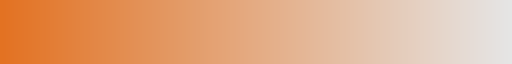

In [4]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 6))
tum_orange_cmap

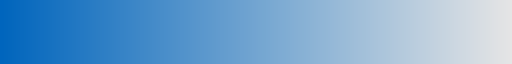

In [5]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 6))
tum_blue_cmap

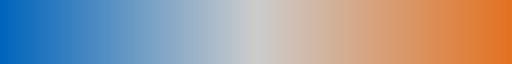

In [6]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.8)
colors = tum_cmap(np.linspace(0,1,5))
tum_cmap

In [22]:
def calc_information(df,E_nom, cap, dva, stage2limits=[], h2limits= [],plot=False):
    print(f"Capacity: {round(df.Q.max(),1)} Ah")
    print(f"Energy: {round(df.E.max(),1)} kWh")
    print(f"SOH_E: {round(df.E.max()/E_nom*100,1)} %")

    x_pos_NE, y_pos_NE = find_max_min(cap, dva, xmin=stage2limits[0], xmax=stage2limits[1], maximum=True)
    print(f"Q_NE: {round(x_pos_NE,1)} Ah")

    print(f"Q_B: {round(df.Q.max()-x_pos_NE,1)} Ah")
    print(f"Capacity_check: {round(x_pos_NE,1)+round(np.max(cap)-x_pos_NE,1)} Ah")
    if h2limits:
        x_pos_PE, yDVA = find_H2_peak(cap, dva, Q_min=h2limits[0],Q_max=h2limits[1])
        maxDVA = np.argmax(yDVA)
        #print(x_pos_PE[maxDVA])
        print(f"Q_PE: {round(df.Q.max()-x_pos_PE[maxDVA],1)} Ah")
        r_squared = r2_score(dva[(cap>=h2limits[0])&(cap<h2limits[1])], yDVA)
        print("R^2:", round(r_squared,3))

    if plot:
        plt.plot(cap,dva)
        plt.ylim([0,1])
        plt.scatter( x_pos_NE, y_pos_NE,label="stage2")
        if h2limits:
            plt.plot(x_pos_PE, yDVA)
            plt.scatter(x_pos_PE[maxDVA], yDVA[maxDVA],label="H2")
            plt.legend()
    return

In [8]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [9]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [10]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [11]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [12]:
read_feather = ReadFeather()
#read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

In [13]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [14]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [15]:
E_nom_VW = 58
E_nom_TM3 = 52.5

## C-Rate

In [16]:
%%capture
df_vw_288_C45 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) # eval was started 2V below so that the steep flank in DVA is not filtered out
df_vw_288_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_C6 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_32A_CEE32_C6.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [17]:
dva_vw_288_C45, cap_vw_288_C45 =dva_extractor.get_dva(time=df_vw_288_C45["time_h"], capacity=df_vw_288_C45["Q"], voltage=filter_func_preprocess_U(df_vw_288_C45["U"]),crop_cap_Ah=(7,180)) # due to the filtering the left side shows a weird behavior. the calculation of the electrode capacities is not affected
dva_vw_288_C17, cap_vw_288_C17 =dva_extractor.get_dva(time=df_vw_288_C17["time_h"], capacity=df_vw_288_C17["Q"], voltage=filter_func_preprocess_U(df_vw_288_C17["U"]),crop_cap_Ah=(1,180))
dva_vw_288_C10, cap_vw_288_C10 =dva_extractor.get_dva(time=df_vw_288_C10["time_h"], capacity=df_vw_288_C10["Q"], voltage=filter_func_preprocess_U(df_vw_288_C10["U"]),crop_cap_Ah=(1,180))
dva_vw_288_C6,  cap_vw_288_C6 =dva_extractor.get_dva(time=df_vw_288_C6["time_h"], capacity=df_vw_288_C6["Q"], voltage=filter_func_preprocess_U(df_vw_288_C6["U"]),crop_cap_Ah=(0,180))

Capacity: 143.6 Ah
Energy: 58.2 kWh
SOH_E: 100.4 %
Q_NE: 82.7 Ah
Q_B: 60.9 Ah
Capacity_check: 143.6 Ah
Q_PE: 10.4 Ah
R^2: 0.944


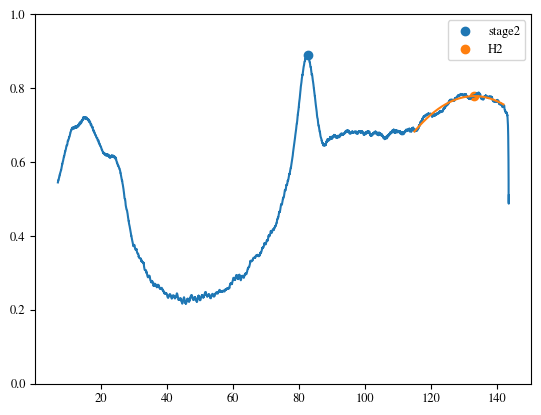

In [27]:
calc_information(df_vw_288_C45, 58, cap_vw_288_C45, dva_vw_288_C45, stage2limits= [70,90], h2limits= [115,142],plot=True)

Capacity: 140.6 Ah
Energy: 57.3 kWh
SOH_E: 98.7 %
Q_NE: 80.9 Ah
Q_B: 59.7 Ah
Capacity_check: 140.60000000000002 Ah
Q_PE: 9.9 Ah
R^2: 0.924


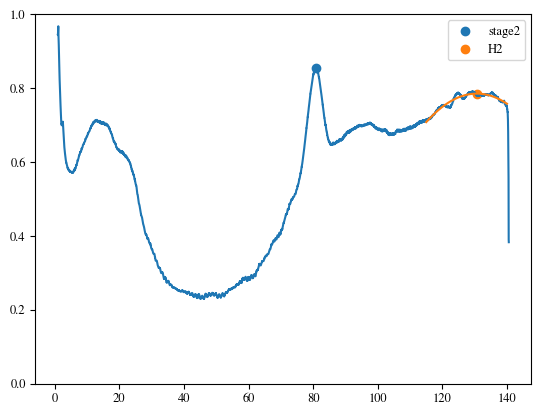

In [30]:
calc_information(df_vw_288_C17, 58, cap_vw_288_C17, dva_vw_288_C17, stage2limits= [70,90], h2limits= [115,140],plot=True)

Capacity: 141.9 Ah
Energy: 57.6 kWh
SOH_E: 99.4 %
Q_NE: 83.7 Ah
Q_B: 58.2 Ah
Capacity_check: 141.9 Ah
Q_PE: 6.9 Ah
R^2: 0.931


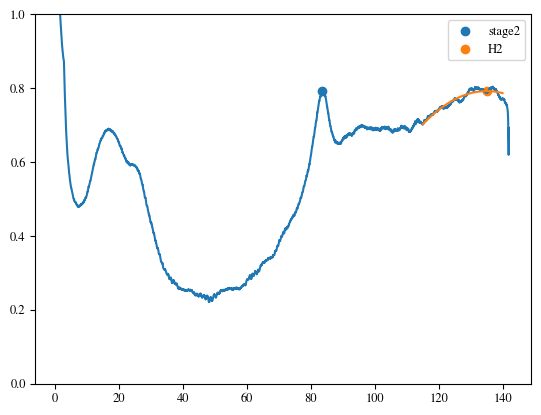

In [33]:
calc_information(df_vw_288_C10, 58, cap_vw_288_C10, dva_vw_288_C10, stage2limits= [70,90], h2limits= [115,140],plot=True)

Capacity: 140.0 Ah
Energy: 57.1 kWh
SOH_E: 98.5 %
Q_NE: 83.5 Ah
Q_B: 56.4 Ah
Capacity_check: 139.9 Ah
Q_PE: 6.6 Ah
R^2: 0.881


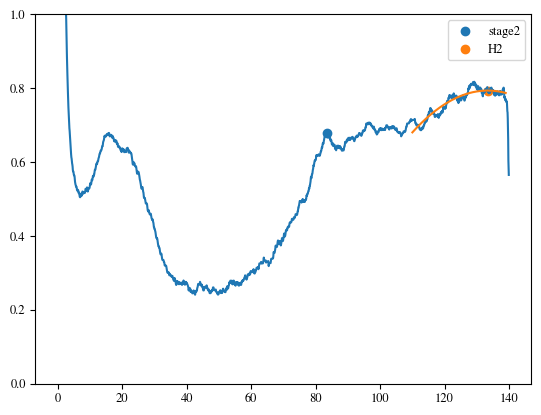

In [138]:
calc_information(df_vw_288_C6, 58, cap_vw_288_C6, dva_vw_288_C6, stage2limits= [70,90], h2limits= [110,139],plot=True)

In [45]:
%%capture
df_tesla_C57 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE7_C57_2022_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C17 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_5A_C17_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C10 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_8A_C10_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C8= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_10A_C8_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 
df_tesla_C5= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_AC_16A_C5_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 

In [46]:
dva_tesla_C57, cap_tesla_C57 =dva_extractor.get_dva(time=df_tesla_C57["time_h"], capacity=df_tesla_C57["Q"], voltage=filter_func_preprocess_U(df_tesla_C57["U"]),crop_cap_Ah=(1,180))
dva_tesla_C17, cap_tesla_C17 =dva_extractor.get_dva(time=df_tesla_C17["time_h"], capacity=df_tesla_C17["Q"], voltage=filter_func_preprocess_U(df_tesla_C17["U"]),crop_cap_Ah=(0,180))
dva_tesla_C10, cap_tesla_C10 =dva_extractor.get_dva(time=df_tesla_C10["time_h"], capacity=df_tesla_C10["Q"], voltage=filter_func_preprocess_U(df_tesla_C10["U"]),crop_cap_Ah=(0,180))
dva_tesla_C5,  cap_tesla_C5 =dva_extractor.get_dva(time=df_tesla_C5["time_h"], capacity=df_tesla_C5["Q"], voltage=filter_func_preprocess_U(df_tesla_C5["U"]),crop_cap_Ah=(0,180))

Capacity: 152.9 Ah
Energy: 54.0 kWh
SOH_E: 102.9 %
Q_NE: 91.7 Ah
Q_B: 61.2 Ah
Capacity_check: 152.9 Ah


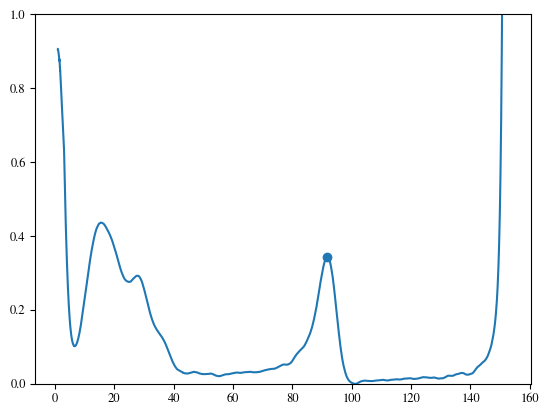

In [47]:
calc_information(df_tesla_C57, 52.5, cap_tesla_C57, dva_tesla_C57, stage2limits= [78,104],plot=True)

Capacity: 150.8 Ah
Energy: 53.3 kWh
SOH_E: 101.5 %
Q_NE: 89.3 Ah
Q_B: 61.5 Ah
Capacity_check: 150.8 Ah


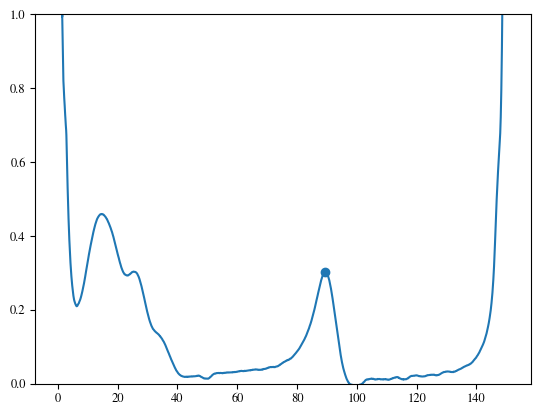

In [48]:
calc_information(df_tesla_C17, 52.5, cap_tesla_C17, dva_tesla_C17, stage2limits= [78,104],plot=True)

Capacity: 150.9 Ah
Energy: 53.5 kWh
SOH_E: 101.9 %
Q_NE: 88.6 Ah
Q_B: 62.3 Ah
Capacity_check: 150.89999999999998 Ah


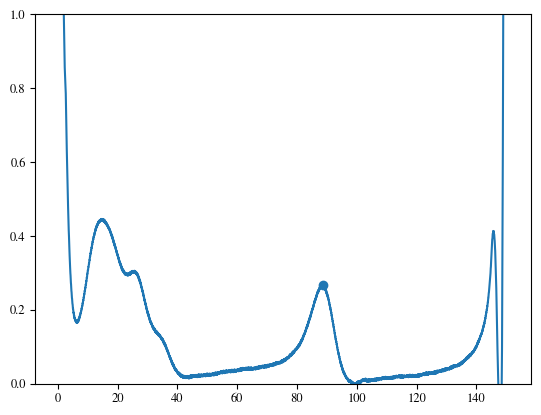

In [49]:
calc_information(df_tesla_C10, 52.5, cap_tesla_C10, dva_tesla_C10, stage2limits= [78,104],plot=True)

Capacity: 151.6 Ah
Energy: 53.9 kWh
SOH_E: 102.6 %
Q_NE: 88.3 Ah
Q_B: 63.3 Ah
Capacity_check: 151.6 Ah


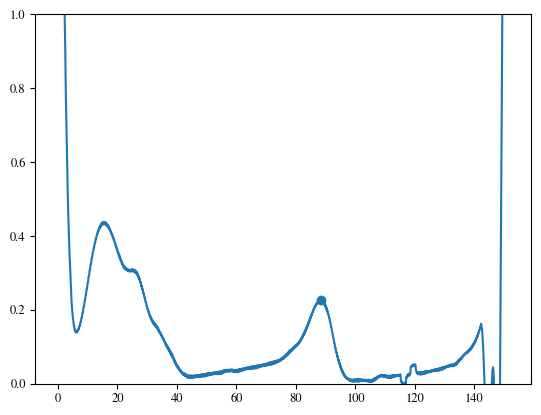

In [50]:
calc_information(df_tesla_C5, 52.5, cap_tesla_C5, dva_tesla_C5, stage2limits= [78,104],plot=True)

## Temperature

In [51]:
%%capture
df_vw_288_outside = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_6A_CEE16_C17_outside.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [52]:
dva_vw_288_hot, cap_vw_288_hot =dva_extractor.get_dva(time=df_vw_288_C17["time_h"], capacity=df_vw_288_C17["Q"], voltage=filter_func_preprocess_U(df_vw_288_C17["U"]),crop_cap_Ah=(1,180))
dva_vw_288_cold, cap_vw_288_cold =dva_extractor.get_dva(time=df_vw_288_outside["time_h"], capacity=df_vw_288_outside["Q"], voltage=filter_func_preprocess_U(df_vw_288_outside["U"]),crop_cap_Ah=(2,180))

Capacity: 140.6 Ah
Energy: 57.3 kWh
SOH_E: 98.7 %
Q_NE: 80.9 Ah
Q_B: 59.7 Ah
Capacity_check: 140.60000000000002 Ah
Q_PE: 9.9 Ah
R^2: 0.924


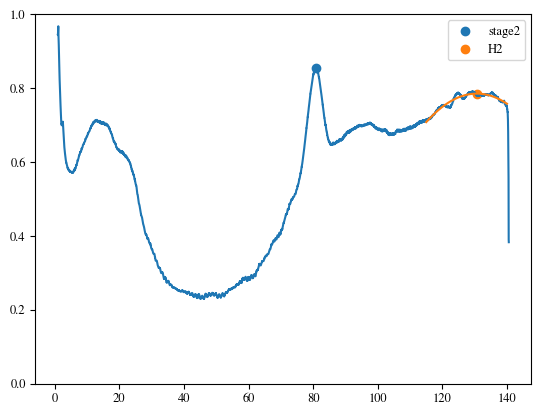

In [56]:
calc_information(df_vw_288_C17, 58, cap_vw_288_hot, dva_vw_288_hot, stage2limits= [70,90], h2limits= [115,140],plot=True)

Capacity: 139.9 Ah
Energy: 57.0 kWh
SOH_E: 98.2 %
Q_NE: 81.9 Ah
Q_B: 58.0 Ah
Capacity_check: 139.9 Ah
Q_PE: 3.5 Ah
R^2: 0.956


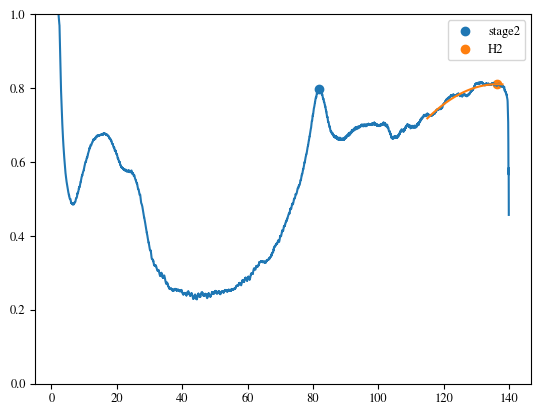

In [58]:
calc_information(df_vw_288_outside, 58, cap_vw_288_cold, dva_vw_288_cold, stage2limits= [70,90], h2limits= [115,138],plot=True)

In [59]:
%%capture
df_tesla_C13_outside= read_feather.read(os.path.join(GeneralConfig.path2data.value,"Tesla","Tesla_JB_6A_CEE16_C13_outside_w_cv.feather"), calc_E = True, lower_voltage=340, upper_voltage=380) 

In [60]:
dva_tesla_hot, cap_tesla_hot =dva_extractor.get_dva(time=df_tesla_C17["time_h"], capacity=df_tesla_C17["Q"], voltage=filter_func_preprocess_U(df_tesla_C17["U"]),crop_cap_Ah=(0,180))
dva_tesla_cold, cap_tesla_cold =dva_extractor.get_dva(time=df_tesla_C13_outside["time_h"], capacity=df_tesla_C13_outside["Q"], voltage=filter_func_preprocess_U(df_tesla_C13_outside["U"]),crop_cap_Ah=(0,180))

Capacity: 150.8 Ah
Energy: 53.3 kWh
SOH_E: 101.5 %
Q_NE: 89.3 Ah
Q_B: 61.5 Ah
Capacity_check: 150.8 Ah


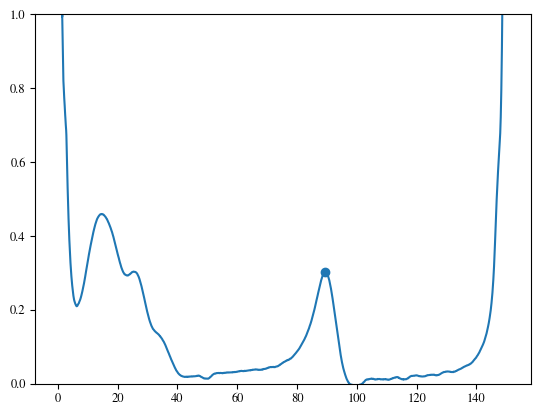

In [61]:
calc_information(df_tesla_C17, 52.5, cap_tesla_hot, dva_tesla_hot, stage2limits= [78,104],plot=True)

Capacity: 147.5 Ah
Energy: 52.6 kWh
SOH_E: 100.2 %
Q_NE: 81.2 Ah
Q_B: 66.3 Ah
Capacity_check: 147.5 Ah


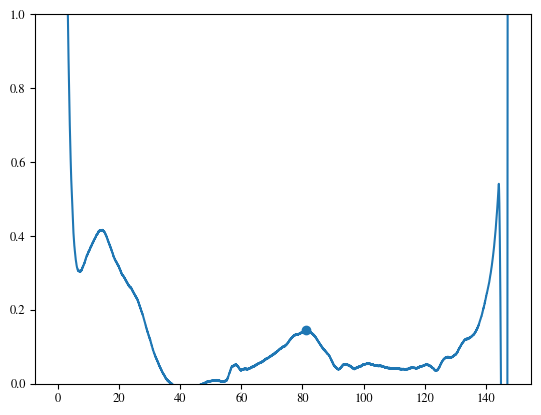

In [62]:
calc_information(df_tesla_C13_outside, 52.5, cap_tesla_cold, dva_tesla_cold, stage2limits= [70,104],plot=True)

## Roundtrip

In [63]:
%%capture
df_vw_288_discharge = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_discharge["E"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge["P"]/1000, df_vw_288_discharge["time_h"], initial=0))
df_vw_288_discharge["Q"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge["I"], df_vw_288_discharge["time_h"], initial=0))

In [64]:
dva_cupra_charge, cap_cupra_charge = dva_extractor.get_dva(time=df_vw_288_C10["time_h"], capacity=df_vw_288_C10["Q"], voltage=filter_func_preprocess_U(df_vw_288_C10["U"]),crop_cap_Ah=(0,180))
dva_cupra_discharge, cap_cupra_discharge = dva_extractor.get_dva(time=df_vw_288_discharge["time_h"], capacity=df_vw_288_discharge["Q"], voltage=filter_func_preprocess_U(df_vw_288_discharge["U"]),crop_cap_Ah=(0,180))

Capacity: 141.9 Ah
Energy: 57.6 kWh
SOH_E: 99.4 %
Q_NE: 83.7 Ah
Q_B: 58.2 Ah
Capacity_check: 141.9 Ah
Q_PE: 6.9 Ah
R^2: 0.931


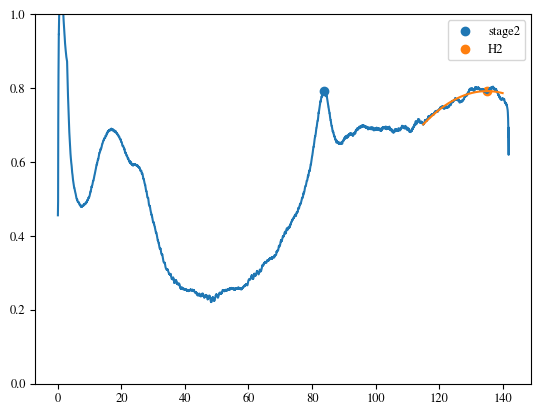

In [66]:
calc_information(df_vw_288_C10, 58, cap_cupra_charge, dva_cupra_charge, stage2limits= [70,90], h2limits= [115,140],plot=True)

Capacity: 135.5 Ah
Energy: 54.8 kWh
SOH_E: 94.4 %
Q_NE: 75.8 Ah
Q_B: 59.7 Ah
Capacity_check: 135.5 Ah
Q_PE: 15.9 Ah
R^2: 0.941


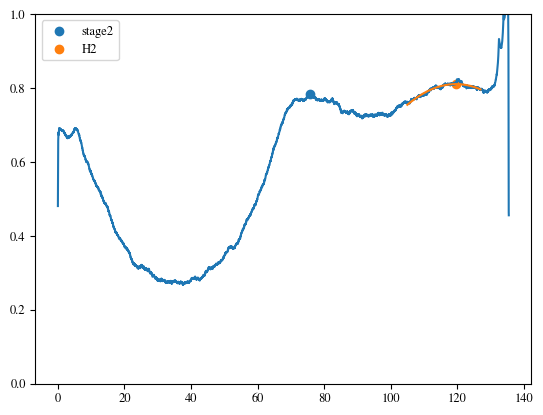

In [69]:
calc_information(df_vw_288_discharge, 58, cap_cupra_discharge, -1*dva_cupra_discharge[::-1], stage2limits= [70,100], h2limits= [105,127],plot=True)

## Relaxation

In [70]:
%%capture
df_vw_pre = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_JB_8A_CEE7_preRelax.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_mid = read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxHighSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_post= read_feather.read(os.path.join(GeneralConfig.path2data.value,"VW","VW_ID3_FTM_8A_CEE7_RelaxLowSOC.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [71]:
dva_vw_pre, cap_vw_pre =dva_extractor.get_dva(time=df_vw_pre["time_h"], capacity=df_vw_pre["Q"], voltage=filter_func_preprocess_U(df_vw_pre["U"]),crop_cap_Ah=(0,180))
dva_vw_mid, cap_vw_mid =dva_extractor.get_dva(time=df_vw_mid["time_h"], capacity=df_vw_mid["Q"], voltage=filter_func_preprocess_U(df_vw_mid["U"]),crop_cap_Ah=(0,180))
dva_vw_post, cap_vw_post =dva_extractor.get_dva(time=df_vw_post["time_h"], capacity=df_vw_post["Q"], voltage=filter_func_preprocess_U(df_vw_post["U"]),crop_cap_Ah=(0,180))

Capacity: 137.9 Ah
Energy: 55.9 kWh
SOH_E: 96.4 %
Q_NE: 83.6 Ah
Q_B: 54.3 Ah
Capacity_check: 137.89999999999998 Ah
Q_PE: 14.0 Ah
R^2: 0.96


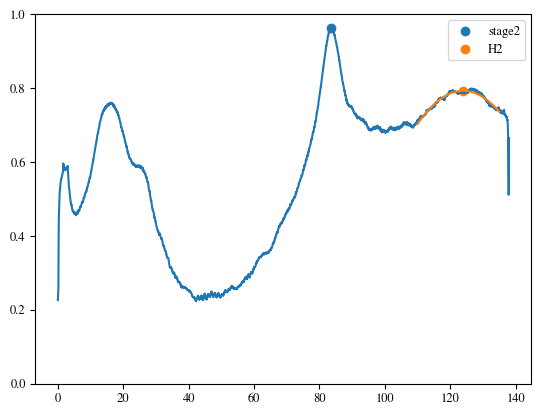

In [76]:
calc_information(df_vw_pre, 58, cap_vw_pre, dva_vw_pre, stage2limits= [70,90], h2limits= [110,135],plot=True)

Capacity: 137.1 Ah
Energy: 55.6 kWh
SOH_E: 95.9 %
Q_NE: 83.2 Ah
Q_B: 53.9 Ah
Capacity_check: 137.1 Ah
Q_PE: 13.3 Ah
R^2: 0.924


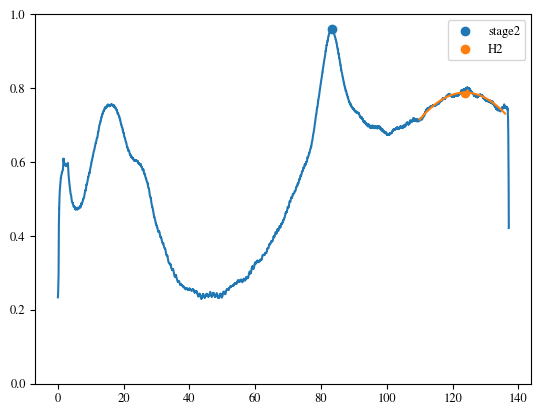

In [80]:
calc_information(df_vw_mid, 58, cap_vw_mid, dva_vw_mid, stage2limits= [70,90], h2limits= [110,136],plot=True)

Capacity: 138.9 Ah
Energy: 56.3 kWh
SOH_E: 97.1 %
Q_NE: 84.4 Ah
Q_B: 54.5 Ah
Capacity_check: 138.9 Ah
Q_PE: 13.8 Ah
R^2: 0.926


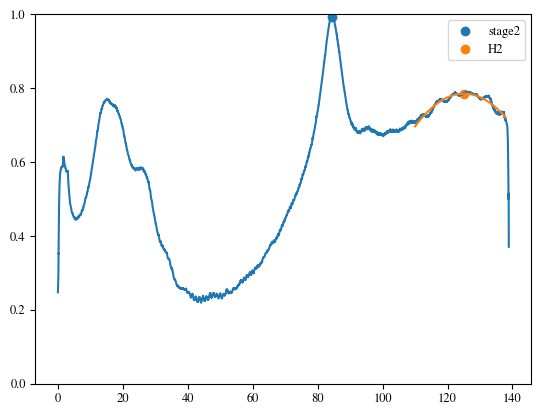

In [83]:
calc_information(df_vw_post, 58, cap_vw_post, dva_vw_post, stage2limits= [70,90], h2limits= [110,138],plot=True)

## Repeatability

In [84]:
%%capture
df_vw_213 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_2 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_3 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability_2.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 

In [85]:
dva_vw_213, cap_vw_213 = dva_extractor.get_dva(time=df_vw_213["time_h"], capacity=df_vw_213["Q"], voltage=filter_func_preprocess_U(df_vw_213["U"]),crop_cap_Ah=(0,180))
dva_vw_213_2, cap_vw_213_2 = dva_extractor.get_dva(time=df_vw_213_2["time_h"], capacity=df_vw_213_2["Q"], voltage=filter_func_preprocess_U(df_vw_213_2["U"]),crop_cap_Ah=(0,180))
dva_vw_213_3, cap_vw_213_3 = dva_extractor.get_dva(time=df_vw_213_3["time_h"], capacity=df_vw_213_3["Q"], voltage=filter_func_preprocess_U(df_vw_213_3["U"]),crop_cap_Ah=(0,180))

Capacity: 144.3 Ah
Energy: 58.4 kWh
SOH_E: 100.7 %
Q_NE: 83.0 Ah
Q_B: 61.3 Ah
Capacity_check: 144.3 Ah
Q_PE: 12.3 Ah
R^2: 0.948


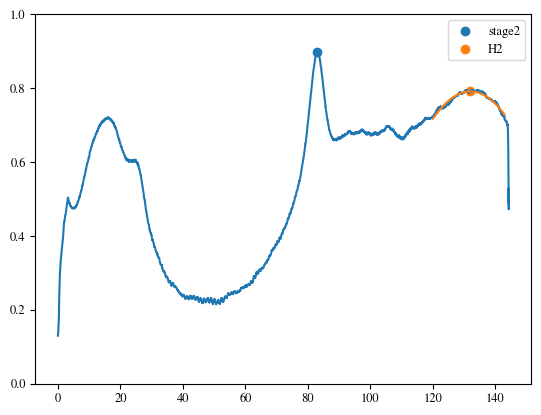

In [88]:
calc_information(df_vw_213, 58, cap_vw_213, dva_vw_213, stage2limits= [70,90], h2limits= [120,143],plot=True)

Capacity: 144.2 Ah
Energy: 58.4 kWh
SOH_E: 100.7 %
Q_NE: 83.4 Ah
Q_B: 60.8 Ah
Capacity_check: 144.2 Ah
Q_PE: 12.3 Ah
R^2: 0.966


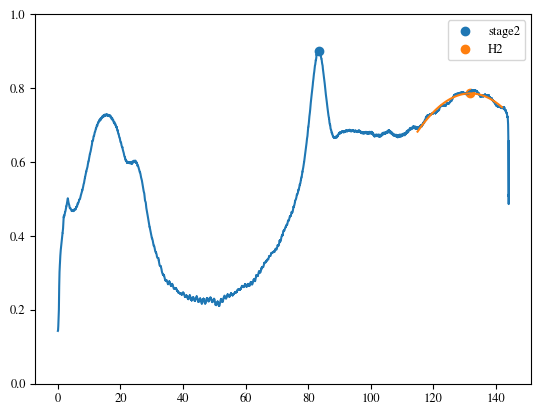

In [91]:
calc_information(df_vw_213_2, 58, cap_vw_213_2, dva_vw_213_2, stage2limits= [70,90], h2limits= [115,142],plot=True)

Capacity: 143.1 Ah
Energy: 58.0 kWh
SOH_E: 100.0 %
Q_NE: 81.8 Ah
Q_B: 61.3 Ah
Capacity_check: 143.1 Ah
Q_PE: 12.8 Ah
R^2: 0.906


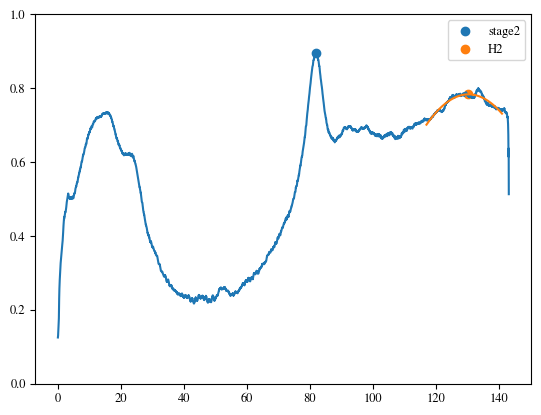

In [147]:
calc_information(df_vw_213_3, 58, cap_vw_213_3, dva_vw_213_3, stage2limits= [70,90], h2limits= [117,141],plot=True)

In [100]:
print(round(np.mean([58.4,58.4,58]),1))
print(round(np.std([58.4,58.4,58]),1))

58.3
0.2


In [101]:
print(round(np.mean([144.3,144.2,143.1]),1))
print(round(np.std([144.3,144.2,143.1]),1))

143.9
0.5


In [102]:
print(round(np.mean([83,83.4,81.8]),1))
print(round(np.std([83,83.4,81.8]),1))

82.7
0.7


In [103]:
print(round(np.mean([61.3,60.8,61.3]),1))
print(round(np.std([61.3,60.8,61.3]),1))

61.1
0.2


In [139]:
print(round(np.mean([12.3,12.3,12.8]),1))
print(round(np.std([12.3,12.3,12.8]),1))

12.5
0.2


## Comparability

In [105]:
%%capture
df_vw_204 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_204_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)
df_vw_349 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_349_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_397 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_397_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)

In [106]:
dva_vw_204, cap_vw_204 = dva_extractor.get_dva(time=df_vw_204["time_h"], capacity=df_vw_204["Q"], voltage=filter_func_preprocess_U(df_vw_204["U"]),crop_cap_Ah=(0,180))
dva_vw_288, cap_vw_288 = dva_extractor.get_dva(time=df_vw_288["time_h"], capacity=df_vw_288["Q"], voltage=filter_func_preprocess_U(df_vw_288["U"]),crop_cap_Ah=(0,180))
dva_vw_349, cap_vw_349 = dva_extractor.get_dva(time=df_vw_349["time_h"], capacity=df_vw_349["Q"], voltage=filter_func_preprocess_U(df_vw_349["U"]),crop_cap_Ah=(0,180))
dva_vw_397, cap_vw_397 = dva_extractor.get_dva(time=df_vw_397["time_h"], capacity=df_vw_397["Q"], voltage=filter_func_preprocess_U(df_vw_397["U"]),crop_cap_Ah=(0,180))

Capacity: 142.1 Ah
Energy: 57.6 kWh
SOH_E: 99.2 %
Q_NE: 81.9 Ah
Q_B: 60.3 Ah
Capacity_check: 142.2 Ah
Q_PE: 11.2 Ah
R^2: 0.948


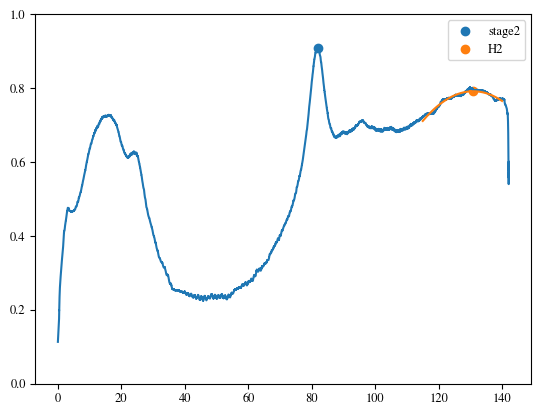

In [108]:
calc_information(df_vw_204, 58, cap_vw_204, dva_vw_204, stage2limits= [70,90], h2limits= [115,140],plot=True)

Capacity: 143.6 Ah
Energy: 58.2 kWh
SOH_E: 100.4 %
Q_NE: 82.7 Ah
Q_B: 60.9 Ah
Capacity_check: 143.6 Ah
Q_PE: 10.4 Ah
R^2: 0.944


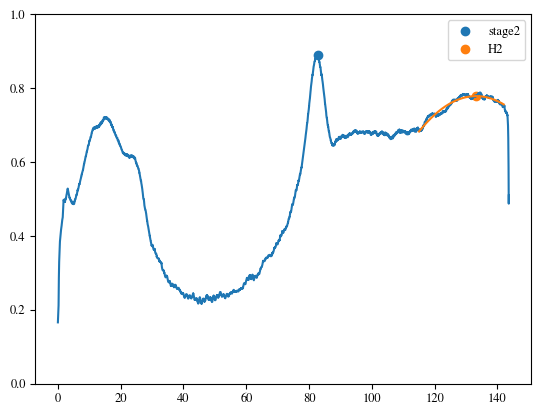

In [111]:
calc_information(df_vw_288, 58, cap_vw_288, dva_vw_288, stage2limits= [70,90], h2limits= [115,142],plot=True)

Capacity: 145.1 Ah
Energy: 58.8 kWh
SOH_E: 101.3 %
Q_NE: 83.7 Ah
Q_B: 61.4 Ah
Capacity_check: 145.1 Ah
Q_PE: 11.9 Ah
R^2: 0.965


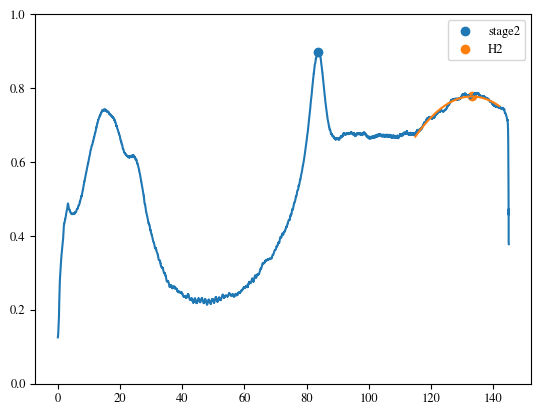

In [113]:
calc_information(df_vw_349, 58, cap_vw_349, dva_vw_349, stage2limits= [70,90], h2limits= [115,142],plot=True)

Capacity: 142.5 Ah
Energy: 57.7 kWh
SOH_E: 99.5 %
Q_NE: 82.5 Ah
Q_B: 60.0 Ah
Capacity_check: 142.5 Ah
Q_PE: 16.2 Ah
R^2: 0.948


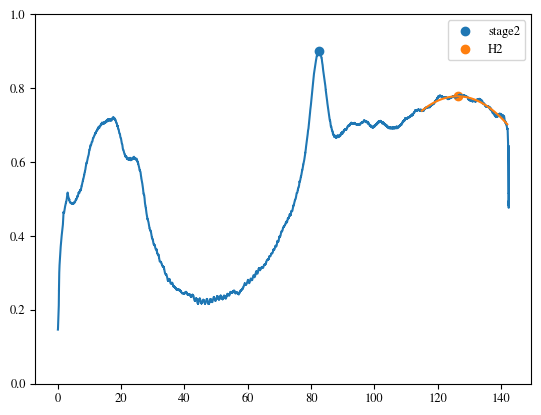

In [115]:
calc_information(df_vw_397, 58, cap_vw_397, dva_vw_397, stage2limits= [70,90], h2limits= [115,142],plot=True)

In [121]:
print(round(np.mean([58.4,57.6,58.2,58.8,57.7]),1))
print(round(np.std([58.4,57.6,58.2,58.8,57.7]),1))

58.1
0.4


In [122]:
print(round(np.mean([144.3,142.1,143.6,145.1,142.5]),1))
print(round(np.std([144.3,142.1,143.6,145.1,142.5]),1))

143.5
1.1


In [123]:
print(round(np.mean([83,81.9,82.7,83.7,82.5]),1))
print(round(np.std([83,81.9,82.7,83.7,82.5]),1))

82.8
0.6


In [124]:
print(round(np.mean([61.3,60.3,60.9,61.4,60]),1))
print(round(np.std([61.3,60.3,60.9,61.4,60]),1))

60.8
0.5


In [144]:
print(round(np.mean([13.3,11.9,11.2,10.4,16.2]),1))
print(round(np.std([13.3,11.9,11.2,10.4,16.2]),1))

12.6
2.0


In [145]:
print(round(np.mean([13.3,11.9,11.2,10.4]),1))
print(round(np.std([13.3,11.9,11.2,10.4]),1))

11.7
1.1


## Analyze Discharge

In [131]:
%%capture
df_vw_288_discharge_test = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_discharge_test2 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 

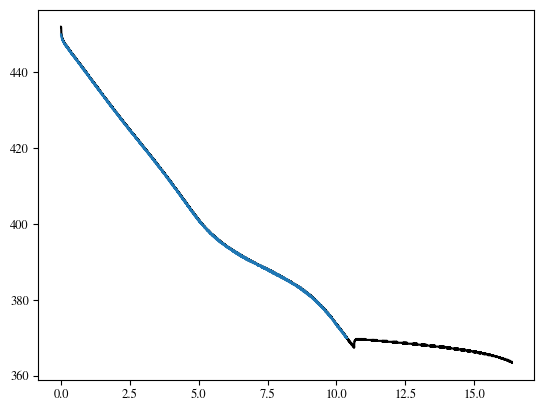

In [132]:
plt.plot(df_vw_288_discharge_test2.time_h,df_vw_288_discharge_test2.U,color="k")
plt.plot(df_vw_288_discharge_test.time_h,df_vw_288_discharge_test.U)

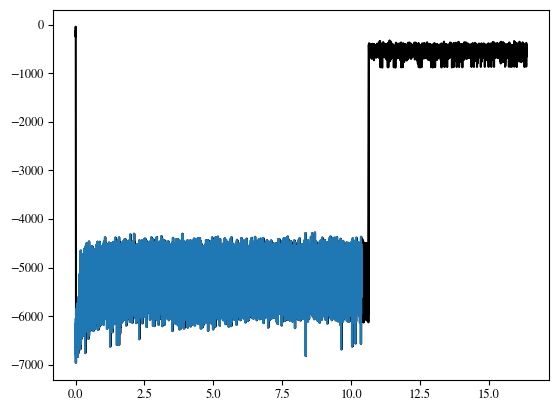

In [133]:
plt.plot(df_vw_288_discharge_test2.time_h,df_vw_288_discharge_test2.P,color="k")
plt.plot(df_vw_288_discharge_test.time_h,df_vw_288_discharge_test.P)

In [134]:
df_vw_288_discharge_test["E"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge_test["P"]/1000, df_vw_288_discharge_test["time_h"], initial=0))
df_vw_288_discharge_test2["E"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge_test2["P"]/1000, df_vw_288_discharge_test2["time_h"], initial=0))

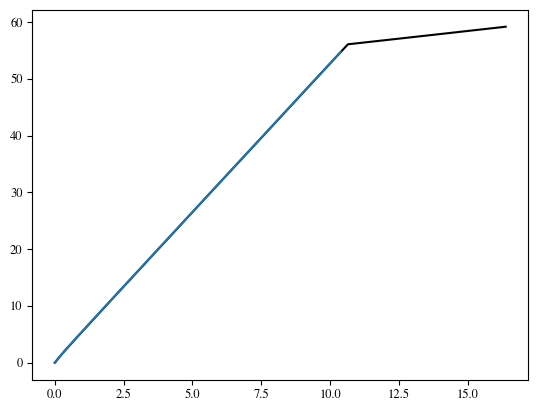

In [135]:
plt.plot(df_vw_288_discharge_test2.time_h,df_vw_288_discharge_test2.E,color="k")
plt.plot(df_vw_288_discharge_test.time_h,df_vw_288_discharge_test.E)